In [1]:
import os
import platform
import subprocess

print("Python version:", platform.python_version())
print("CUDA visible devices:", os.environ.get("CUDA_VISIBLE_DEVICES", "Not set"))

print("\n=== nvidia-smi ===")
try:
    subprocess.run(["nvidia-smi"], check=True)
except Exception as exc:
    print("Không chạy được nvidia-smi:", exc)

Python version: 3.11.13
CUDA visible devices: Not set

=== nvidia-smi ===
Wed Oct 22 04:21:21 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 560.35.03              Driver Version: 560.35.03      CUDA Version: 12.6     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   36C    P8             10W /   70W |       1MiB /  15360MiB |      0%      Default |
|                                         |                       

In [2]:
!pip install --quiet --no-deps torch==2.1.2 torchvision==0.16.2 torchaudio==2.1.2 --index-url https://download.pytorch.org/whl/cu118
!pip install --quiet --no-deps numpy==1.26.4 pillow==10.4.0 torchvision==0.16.2 tqdm==4.66.5 yaml==0.2.5

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 GB 460.0 kB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.1/6.1 MB 81.2 MB/s eta 0:00:00:00:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 78.9 MB/s eta 0:00:00:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.6/57.6 kB 2.3 MB/s eta 0:00:00
ERROR: Could not find a version that satisfies the requirement yaml==0.2.5 (from versions: none)
ERROR: No matching distribution found for yaml==0.2.5


In [3]:
!git clone https://github.com/Trantuan24/InstaManip.git
%cd /kaggle/working/InstaManip

Cloning into 'InstaManip'...
remote: Enumerating objects: 473, done.
remote: Counting objects: 100% (204/204), done.
remote: Compressing objects: 100% (156/156), done.
remote: Total 473 (delta 82), reused 153 (delta 42), pack-reused 269 (from 3)
Receiving objects: 100% (473/473), 49.09 MiB | 13.60 MiB/s, done.
Resolving deltas: 100% (106/106), done.
Updating files: 100% (256/256), done.
/kaggle/working/InstaManip


In [4]:
from pathlib import Path
import json
import shutil

DATASET_ROOT = Path("/kaggle/input/ip2p-datasets/instruct_pix2pix_full")
DATA_ROOT = Path("data")
image_dir = DATA_ROOT / "ip2p"
train_dir = DATA_ROOT / "train"
image_dir.mkdir(parents=True, exist_ok=True)
train_dir.mkdir(parents=True, exist_ok=True)

jsonl_path = train_dir / "ip2p_subset.jsonl"
group_map_path = DATA_ROOT / "ip2p_group_instruct.json"

if jsonl_path.exists():
    jsonl_path.unlink()

group_map = {}

In [5]:
from PIL import Image

with jsonl_path.open("w", encoding="utf-8") as outfile:
    for group_dir in sorted(DATASET_ROOT.iterdir()):
        if not group_dir.is_dir():
            continue
        group_name = group_dir.name

        target_path = image_dir / group_name
        if target_path.exists():
            if not (target_path.is_symlink() or target_path.is_dir()):
                target_path.unlink()
        else:
            os.symlink(group_dir, target_path)

        prompt_file = group_dir / "prompt.json"
        if not prompt_file.exists():
            alt_prompts = list(group_dir.glob("prompt*.json"))
            prompt_file = alt_prompts[0] if alt_prompts else None

        instruction = ""
        caption_before = ""
        caption_after = ""
        if prompt_file and prompt_file.exists():
            prompt_text = prompt_file.read_text(encoding="utf-8").strip()
            entries = []
            if prompt_text:
                try:
                    parsed = json.loads(prompt_text)
                    entries = parsed if isinstance(parsed, list) else [parsed]
                except json.JSONDecodeError:
                    for line in prompt_text.splitlines():
                        line = line.strip()
                        if not line:
                            continue
                        try:
                            entries.append(json.loads(line))
                        except json.JSONDecodeError:
                            continue
            if entries:
                first = entries[0]
                instruction = first.get("edit") or first.get("instruction") or ""
                caption_before = first.get("input") or first.get("caption_before") or ""
                caption_after = first.get("output") or first.get("caption_after") or ""

        metadata_file = group_dir / "metadata.jsonl"
        if not metadata_file.exists():
            continue

        seeds = []
        with metadata_file.open("r", encoding="utf-8") as f:
            for line in f:
                line = line.strip()
                if not line:
                    continue
                try:
                    record = json.loads(line)
                except json.JSONDecodeError:
                    continue
                if "seed" in record:
                    seeds.append(record["seed"])

        if not seeds:
            continue

        group_map[group_name] = []

        for seed in seeds:
            src_name = f"{seed}_0.jpg"
            tgt_name = f"{seed}_1.jpg"
            if not (group_dir / src_name).exists() or not (group_dir / tgt_name).exists():
                continue

            entry = {
                "source_image": f"{group_name}/{src_name}",
                "target_image": f"{group_name}/{tgt_name}",
                "instruction": instruction,
                "caption_before": caption_before,
                "caption_after": caption_after,
            }
            outfile.write(json.dumps(entry) + "\n")

            base_id = str(seed)
            if base_id not in group_map[group_name]:
                group_map[group_name].append(base_id)

print("Số mẫu ghi:", sum(1 for _ in jsonl_path.open("r", encoding="utf-8")))

with group_map_path.open("w", encoding="utf-8") as f:
    json.dump(group_map, f, indent=2)

print("Đã tạo", jsonl_path)
print("Đã tạo", group_map_path)
print("Tổng group:", len(group_map))

Số mẫu ghi: 36126
Đã tạo data/train/ip2p_subset.jsonl
Đã tạo data/ip2p_group_instruct.json
Tổng group: 10434


In [6]:
!cd /kaggle/working/InstaManip && python scripts/train_kaggle_mock.py \
    --config configs_kaggle/mock_training_large.yaml

Epoch 1/12: 100%|███████████████████████████| 2710/2710 [03:56<00:00, 11.45it/s]
/usr/local/lib/python3.11/dist-packages/torch/nn/modules/transformer.py:380: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. (Triggered internally at ../aten/src/ATen/NestedTensorImpl.cpp:178.)
  output = torch._nested_tensor_from_mask(output, src_key_padding_mask.logical_not(), mask_check=False)
[Validation] Epoch 1: loss=0.240887
Epoch 2/12: 100%|███████████████████████████| 2710/2710 [03:08<00:00, 14.34it/s]
[Validation] Epoch 2: loss=0.160486
Đã lưu checkpoint tại /kaggle/working/train_output_kaggle_mock_large/mock_model_epoch2.pt
Epoch 3/12: 100%|███████████████████████████| 2710/2710 [03:09<00:00, 14.28it/s]
[Validation] Epoch 3: loss=0.121206
Epoch 4/12: 100%|███████████████████████████| 2710/2710 [03:09<00:00, 14.33it/s]
[Validation] Epoch 4: loss=0.096302
Đã lưu checkpoint tại /kaggle/working/train_output_kaggle_mock_large/mock_model_epoch4.

=== Training summary ===
dataset_size: 36126
train_size: 32513
val_size: 3613
total_steps: 32520
best_val_loss: 0.0506654704931741
best_epoch: 11
best_checkpoint: /kaggle/working/train_output_kaggle_mock_large/mock_model_epoch10.pt
elapsed_seconds: 2558.3940222263336


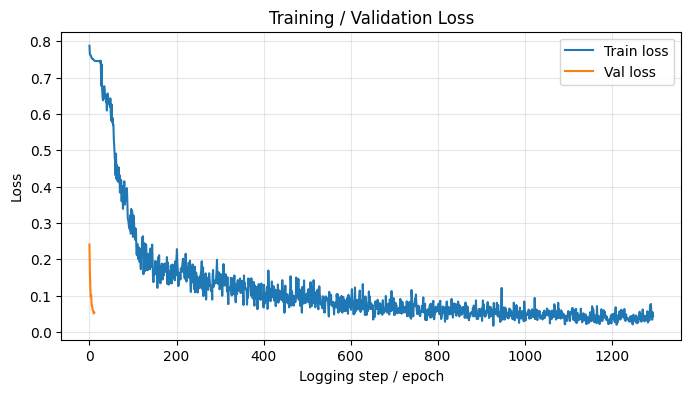

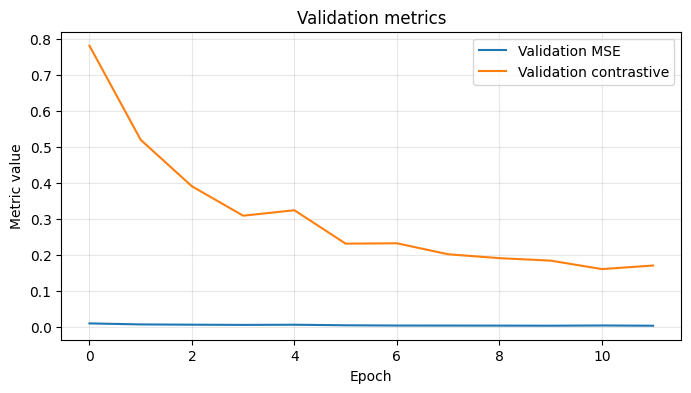

In [10]:
import json
import matplotlib.pyplot as plt

OUTPUT_DIR = Path("/kaggle/working/train_output_kaggle_mock_large")
log_path = OUTPUT_DIR / "training_log.json"

if log_path.exists():
    with log_path.open("r", encoding="utf-8") as f:
        history = json.load(f)

    train_losses = history.get("train_loss", [])
    val_losses = history.get("val_loss", [])
    val_mse = history.get("val_mse", [])
    val_contrastive = history.get("val_contrastive", [])
    summary = history.get("summary", {})

    if summary:
        print("=== Training summary ===")
        for key, value in summary.items():
            print(f"{key}: {value}")

    plt.figure(figsize=(8, 4))
    if train_losses:
        plt.plot(train_losses, label="Train loss")
    if val_losses:
        plt.plot(val_losses, label="Val loss")
    plt.xlabel("Logging step / epoch")
    plt.ylabel("Loss")
    plt.title("Training / Validation Loss")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    if val_mse or val_contrastive:
        plt.figure(figsize=(8, 4))
        if val_mse:
            plt.plot(val_mse, label="Validation MSE")
        if val_contrastive:
            plt.plot(val_contrastive, label="Validation contrastive")
        plt.xlabel("Epoch")
        plt.ylabel("Metric value")
        plt.title("Validation metrics")
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()
else:
    print("Không tìm thấy training_log.json để vẽ.")